In [34]:
import pandas as pd
import numpy as np

In [35]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [36]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

In [37]:
cat_cols = ['sex', 'smoker', 'region']
df[cat_cols] = df[cat_cols].astype('category')

pd.DataFrame(df.dtypes, columns=['Dtype']).T

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,category,float64,int64,category,category,float64


In [38]:
null = df.isnull().sum()
ratio = (null / df.shape[0]) * 100
pd.DataFrame({"Null_Count": null, "Ratio (%)": ratio}).T

,age,sex,bmi,children,smoker,region,charges
Null_Count,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Ratio (%),0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [39]:
num_cols = df.select_dtypes(include=['number']).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR
    
    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values
    
    print(f"Column:{col}")
    print(f"Lower Outliers count: {len(lower_outliers)}")
    print(f"Upper Outliers count: {len(upper_outliers)}\n")

Column:age
Lower Outliers count: 0
Upper Outliers count: 0

Column:bmi
Lower Outliers count: 0
Upper Outliers count: 9

Column:children
Lower Outliers count: 0
Upper Outliers count: 0

Column:charges
Lower Outliers count: 0
Upper Outliers count: 139



In [40]:
feature_num_cols = [c for c in num_cols if c != 'charges']

for col in feature_num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_fence = Q1 - 1.5 * IQR
    upper_fence = Q3 + 1.5 * IQR

    lower_outliers = df[df[col] < lower_fence][col].values
    upper_outliers = df[df[col] > upper_fence][col].values

    df[col] = df[col].replace(lower_outliers, lower_fence)
    df[col] = df[col].replace(upper_outliers, upper_fence)

    print(f"Column: {col} -> Max after capping: {df[col].max()}")

Column: age -> Max after capping: 64
Column: bmi -> Max after capping: 47.31500000000001
Column: children -> Max after capping: 5


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

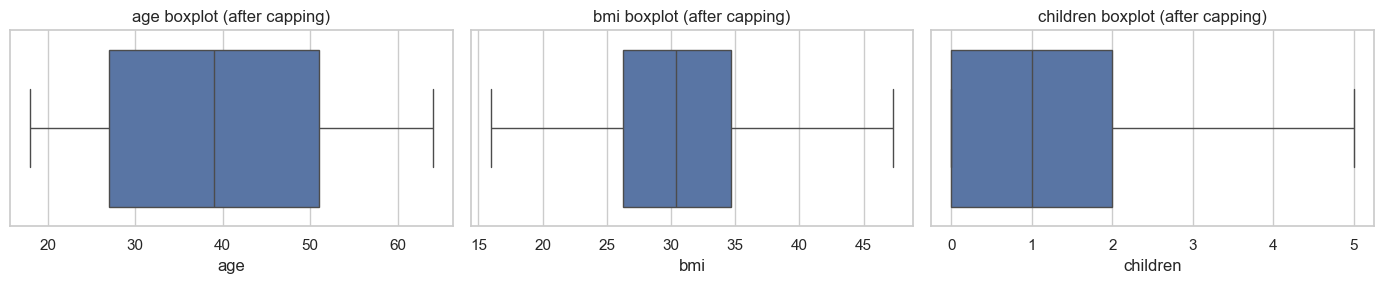

In [42]:
plt.figure(figsize=(14, 3))
for i, col in enumerate(feature_num_cols):
    plt.subplot(1, len(feature_num_cols), i + 1)
    sns.boxplot(x=df[col])
    plt.title(f"{col} boxplot (after capping)")
plt.tight_layout()
plt.show()

In [43]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.650247,1.095737,13279.121487
std,14.044333,6.059655,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,47.315000,5.000000,63770.428010


In [44]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


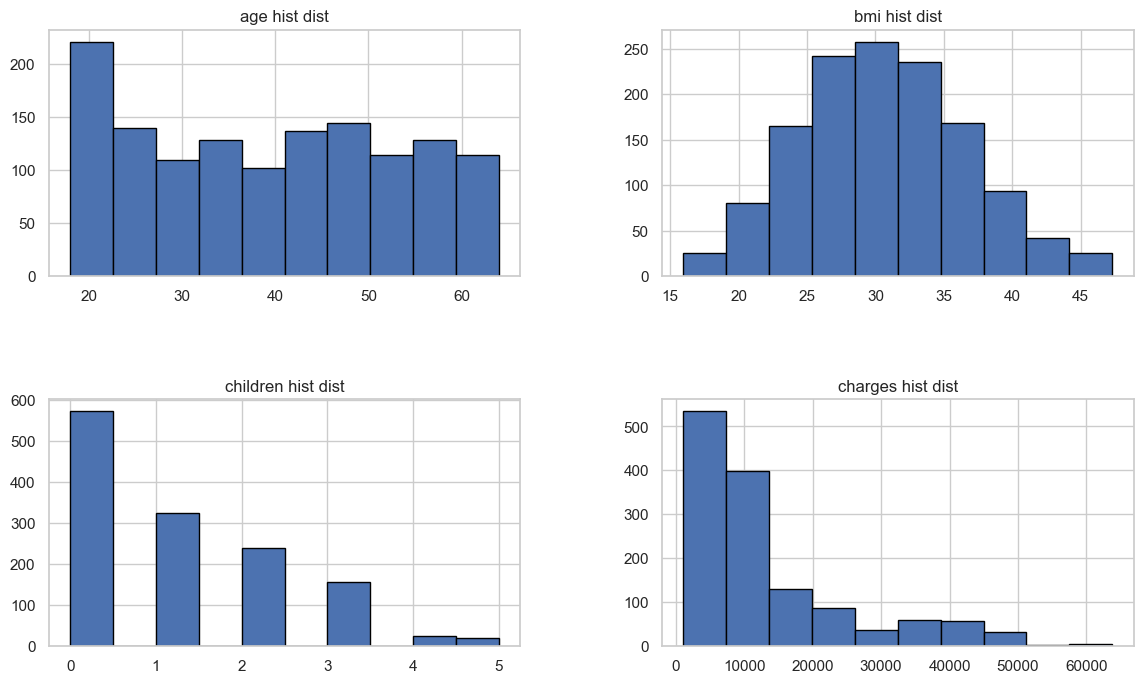

In [45]:
plt.figure(figsize=(14, 8))
for i, col in enumerate(num_cols):
    plt.subplot(2, 2, i + 1)
    plt.hist(df[col], edgecolor="black")
    plt.title(f"{col} hist dist")
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()


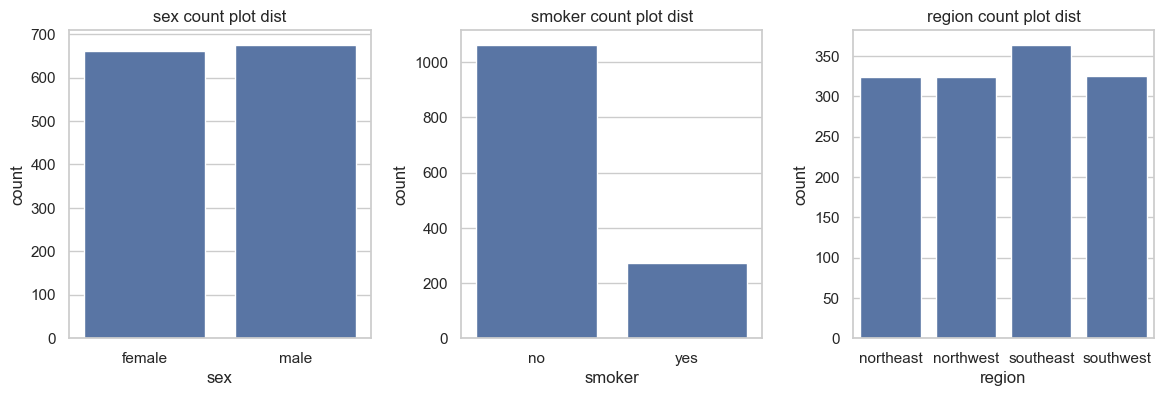

In [46]:
plt.figure(figsize=(14, 4))
for i, col in enumerate(cat_cols):
    plt.subplot(1, 3, i + 1)
    sns.countplot(x=col, data=df)
    plt.title(f"{col} count plot dist")
plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()


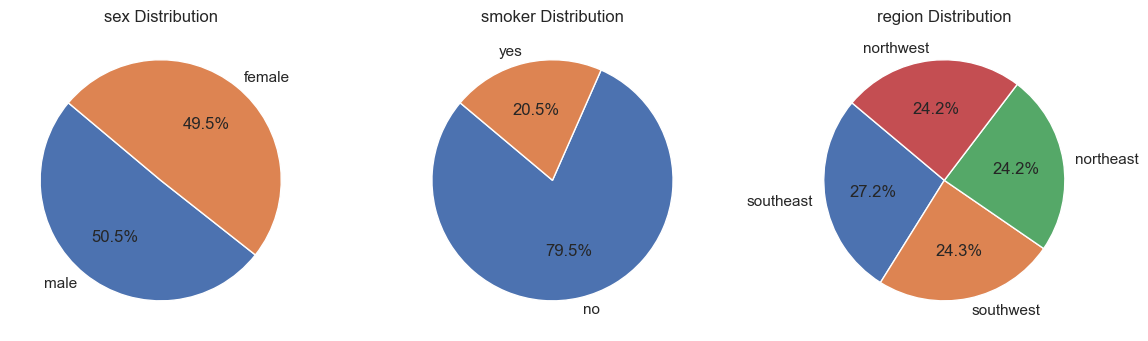

In [47]:
plt.figure(figsize=(14, 4))

for i, col in enumerate(cat_cols):
    plt.subplot(1, 3, i + 1)

    uniq = df[col].value_counts()
    count = uniq.values
    category = uniq.index

    plt.pie(count, labels=category, startangle=140, autopct="%1.1f%%")
    plt.title(f"{col} Distribution")

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

In [48]:
import plotly.express as px
fig = px.pie(df, names="smoker", color_discrete_sequence=px.colors.qualitative.Pastel, hole=0.7)
fig.show()

In [50]:
fig = px.scatter(df, x="bmi", y="charges", color="smoker", title="BMI vs Charges")
fig.show()

In [49]:
df.duplicated().sum()

0